# 04 — A particle simulation certified by an exact solution

**What this shows.** The project's rule in its purest form: *an exact result certifies a floating-point computation,
never the reverse.* The simulation is a stochastic particle method (DSMC, Nanbu/Bird type) for the spatially homogeneous
Boltzmann equation, with 3D Maxwell molecules and isotropic scattering. The certificate is the exact
Bobylev–Krook–Wu (BKW) solution. No parameter is fitted. The BKW time scale $K(t) = 1-(1-K_0)e^{-t/6}$ is *derived*
from the moment equation $\dot m_4 = -(m_4-15)/3$ of this collision normalisation, and checked symbolically below.

**Time:** about two minutes at moderate particle numbers. The full run with $N = 10^6$ is
`python3 simulations/large_scale/dsmc_bkw.py`; its stored summary is shown at the end.

In [1]:
# Locate the repository root, so this notebook runs from any working directory inside it.
import sys, contextlib, io
from pathlib import Path
ROOT = Path.cwd().resolve()
while not (ROOT / "agora_swarm").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

def quiet():
    """The engine narrates each step on stdout; hide that inside loops."""
    return contextlib.redirect_stdout(io.StringIO())

import numpy as np, sympy as sp, mpmath as mp
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
print("repository:", ROOT.name)

repository: SocrateAI-Scientific-Agora-Physique-Cinetique


In [2]:
sys.path.insert(0, str(ROOT / "simulations/large_scale"))
import dsmc_bkw as D
print("symbolic check of the BKW time scale:", D.check_bkw_time_scaling())

symbolic check of the BKW time scale: True


## One run against the exact curves

$m_4 = E|v|^4$ and $m_6 = E|v|^6$ have closed forms along BKW, and the relative entropy $H(f\,|\,M)$ must decrease
(H-theorem). The initial state $K_0 = 3/5$ is the extreme BKW profile, which vanishes at $v=0$. The particle estimate
of $H$ uses a histogram of speeds with $B$ bins, which has a positive bias of about $(B-1)/2N$. Once the exact $H$
falls below that floor, the estimate levels off: that is statistics, not physics.

N = 1e5: 748,681 collisions in 6.6 s; errors vs exact: {'rms_rel_m4': '2.4e-03', 'rms_rel_m6': '7.4e-03', 'max_abs_m4': '7.6e-02', 'rms_abs_H': '6.8e-04', 'energy_drift': '4.4e-16', 'momentum_max': '9.8e-17'}


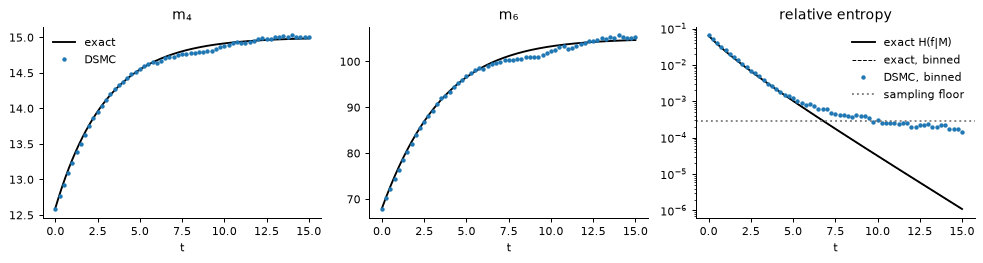

In [3]:
res = D.run(100_000, seed=1, t_end=15.0, dt=1e-2)
t, tt = res["t"], np.linspace(0, 15, 300)
print(f"N = 1e5: {res['collisions']:,} collisions in {res['wall']:.1f} s; errors vs exact:", {k: f"{v:.1e}" for k, v in D.errors(res).items()})
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].plot(tt, D.m4_exact(tt), "k-", label="exact"); ax[0].plot(t, res["m4"], "o", ms=2.5, label="DSMC"); ax[0].set(xlabel="t", title="m₄"); ax[0].legend(frameon=False)
ax[1].plot(tt, D.m6_exact(tt), "k-"); ax[1].plot(t, res["m6"], "o", ms=2.5); ax[1].set(xlabel="t", title="m₆")
ax[2].semilogy(tt, [D.entropy_exact(k) for k in D.K_of_t(tt)], "k-", label="exact H(f|M)")
ax[2].semilogy(t, [D.binned_kl_exact(res["edges"], k) for k in D.K_of_t(t)], "k--", lw=0.8, label="exact, binned")
ax[2].semilogy(t, np.maximum(res["H_binned"], 1e-7), "o", ms=2.5, label="DSMC, binned")
ax[2].axhline((len(res["edges"]) - 2) / (2 * res["N"]), ls=":", color="grey", label="sampling floor"); ax[2].set(xlabel="t", title="relative entropy"); ax[2].legend(frameon=False)
plt.tight_layout(); plt.show()

## The velocity marginal

The exact $v_x$ marginal is $g(x) = (2\pi K)^{-1/2}e^{-x^2/2K}\,[\tfrac{5K-3}{2K} + \tfrac{(1-K)(x^2+2K)}{2K^2}]$.
At $t=0$ it is flat-topped, and it relaxes to the Maxwellian.

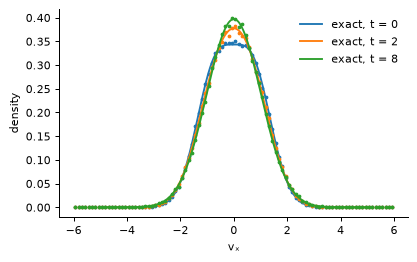

In [4]:
xc = 0.5 * (res["xedges"][1:] + res["xedges"][:-1]); w = np.diff(res["xedges"]); xs = np.linspace(-5, 5, 300)
plt.figure(figsize=(5, 3))
for ti in (0, 2, 8):
    i = int(np.argmin(abs(t - ti))); K = float(D.K_of_t(t[i]))
    line, = plt.plot(xs, D.marginal_exact(xs, K), label=f"exact, t = {t[i]:g}")
    plt.plot(xc, res["vx_hist"][i] / (res["N"] * w), "o", ms=2, color=line.get_color())
plt.xlabel("vₓ"); plt.ylabel("density"); plt.legend(frameon=False); plt.show()

## Convergence in the number of particles

Monte Carlo error falls like $N^{-1/2}$. The time-step bias is known in closed form and stays far below it. So the
distance to the exact curve is *all* statistical, and that is what makes the exact solution a certificate.

N =   5000: RMS relative error of m4 = 1.02e-02


N =  20000: RMS relative error of m4 = 4.59e-03


N =  80000: RMS relative error of m4 = 2.00e-03
empirical rate N^-0.59 (theory N^-0.5); closed-form time-step bias at dt = 1e-2: 9.8e-05


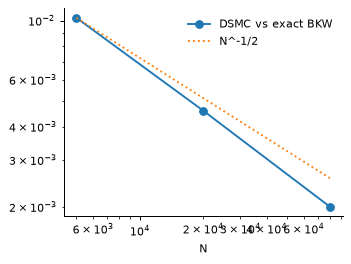

In [5]:
Ns, errs = [5_000, 20_000, 80_000], []
for N in Ns:
    e = [D.errors(D.run(N, seed, t_end=8.0, dt=1e-2))["rms_rel_m4"] for seed in (1, 2, 3)]
    errs.append(np.mean(e)); print(f"N = {N:>6}: RMS relative error of m4 = {errs[-1]:.2e}")
slope = np.polyfit(np.log(Ns), np.log(errs), 1)[0]
print(f"empirical rate N^{slope:.2f} (theory N^-0.5); closed-form time-step bias at dt = 1e-2: "
      f"{np.abs(D.discretisation_bias_m4(np.linspace(0, 8, 33), 1e-2)).max() / 15:.1e}")
plt.figure(figsize=(4, 3)); plt.loglog(Ns, errs, "o-", label="DSMC vs exact BKW")
plt.loglog(Ns, errs[0] * (np.array(Ns) / Ns[0]) ** -0.5, ":", label="N^-1/2"); plt.xlabel("N"); plt.legend(frameon=False); plt.show()

## The stored large run

This is the output of `simulations/large_scale/dsmc_bkw.py`, which goes up to $N = 10^6$ over $t \in [0, 30]$.

In [6]:
import json
p = ROOT / "alexandrie_data/SIMULATIONS/dsmc_bkw_summary.json"
if p.exists():
    s = json.loads(p.read_text())
    for N, v in s["by_N"].items():
        print(f"N = {int(N):>8}: RMS rel. error m4 {v['rms_rel_m4']:.2e}, m6 {v['rms_rel_m6']:.2e} ({v['seeds']} seeds, {v['wall_s']:.0f} s each)")
    print(f"rate N^{s['convergence_slope_m4']:.3f}; exact entropy strictly decreasing: {s['entropy_exact_strictly_decreasing']}")
else:
    print("run  python3 simulations/large_scale/dsmc_bkw.py  to produce the large run")

N =    10000: RMS rel. error m4 6.80e-03, m6 2.17e-02 (16 seeds, 5 s each)
N =   100000: RMS rel. error m4 2.01e-03, m6 6.36e-03 (4 seeds, 17 s each)
N =  1000000: RMS rel. error m4 6.22e-04, m6 2.13e-03 (2 seeds, 135 s each)
rate N^-0.519; exact entropy strictly decreasing: True
